# 🎓 Predicción de estudiantes en riesgo académico

En este proyecto se analiza qué factores influyen en el rendimiento académico, con un enfoque en la detección temprana de estudiantes en riesgo (calificación F).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📁 Descripción del dataset

El dataset contiene información de 1,000,000 estudiantes con las siguientes variables:

- `weekly_self_study_hours`: horas de autoestudio semanal
- `attendance_percentage`: porcentaje de asistencia
- `class_participation`: nivel de participación en clase
- `total_score`: puntaje final
- `grade`: calificación categórica (A–F)

El dataset no presenta valores nulos y tiene una estructura limpia, lo que sugiere que podría ser sintético.

In [ ]:
df = pd.read_csv('student_performance.csv')

In [ ]:
df.columns

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,0
class_participation,0
total_score,0
grade,0


In [ ]:
df["passed"] = (df["total_score"]>=50).astype(int)

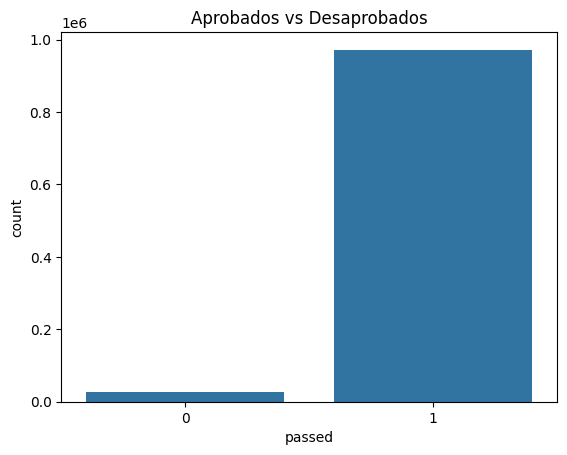

In [ ]:
sns.countplot(x ="passed", data = df)
plt.title("Aprobados vs Desaprobados")
plt.show()

## 🎯 Definición del problema

El objetivo es identificar estudiantes en riesgo académico.

Se define como "en riesgo" a aquellos estudiantes con calificación **F**.

## ⚙️ Creación de la variable objetivo

Se crea la variable binaria `at_risk`, donde:

- 1 → estudiante en riesgo (F)
- 0 → no está en riesgo

In [ ]:
df["at_risk"] = (df["grade"] == "F").astype(int)
features = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation"
]

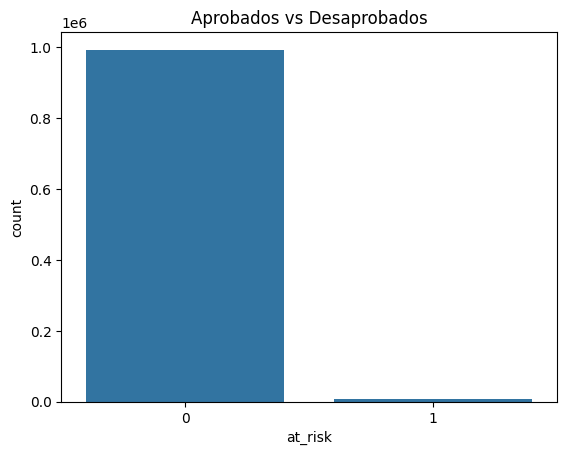

at_risk
0    0.993796
1    0.006204
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x = "at_risk", data = df)
plt.title("Aprobados vs Desaprobados")
plt.show()
print(df["at_risk"].value_counts(normalize = True))

## 📊 Distribución del target

El dataset presenta un desbalance extremo, donde menos del 1% de los estudiantes están en riesgo (F).
Esto implica que métricas como accuracy no serán adecuadas para evaluar el modelo.

## 📊 Análisis de variables
Para ello, haremos uso del Heatmap de correlación, el cual será implementado por medio del uso de la librería seaborn

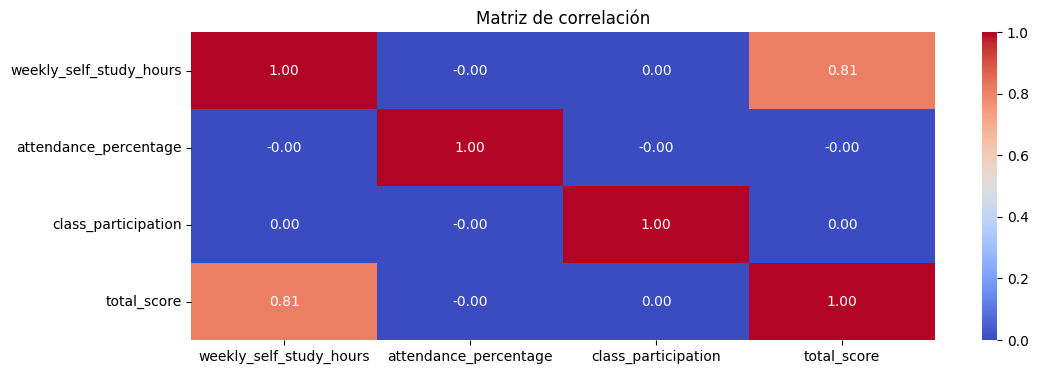

In [ ]:
correlacion = df[[
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]].corr()
plt.figure(figsize = (12, 4))
sns.heatmap(correlacion, annot  = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Matriz de correlación")
plt.show()

## Correlación entre variables

La variable `weekly_self_study_hours` muestra una fuerte correlación positiva con el puntaje total (~0.8).

Por otro lado, `attendance_percentage` y `class_participation` presentan correlaciones cercanas a cero, lo que sugiere que tienen poca relación con el rendimiento académico en este dataset.

## Relación entre horas de estudio y puntaje

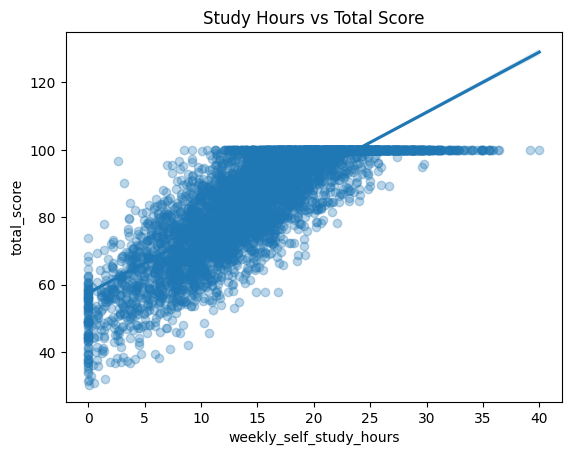

In [ ]:
sns.regplot( x = "weekly_self_study_hours", y = "total_score", data = df.sample(5000), scatter_kws = {"alpha":0.3})
plt.title("Study Hours vs Total Score")
plt.show()



En general, mientras más horas estudian, mejor les va. Pero no es una relación perfecta, porque los datos están algo dispersos. Además, cuando las notas se acercan a 100, ya no suben mucho más, como si hubiera un límite, y eso hace que la relación no se vea tan clara.

## Relación entre asistencia y puntaje

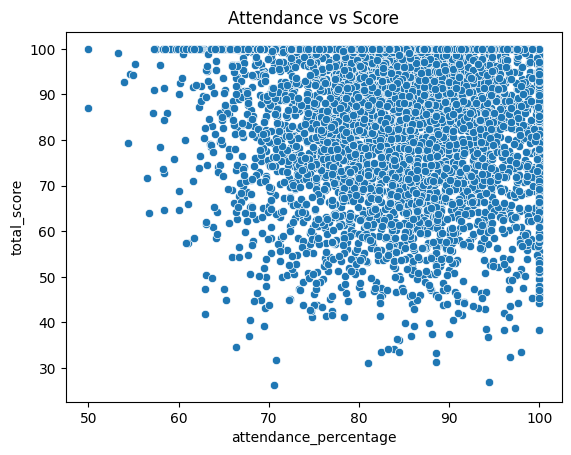

In [ ]:
sns.scatterplot(
    x="attendance_percentage",
    y="total_score",
    data=df.sample(5000)
)
plt.title("Attendance vs Score")
plt.show()

No se observa una relación clara entre el porcentaje de asistencia y el puntaje total.

Los datos aparecen dispersos sin una tendencia definida, lo que sugiere que la asistencia tiene poco impacto en el rendimiento en este dataset.

## Relación entre participación y puntaje

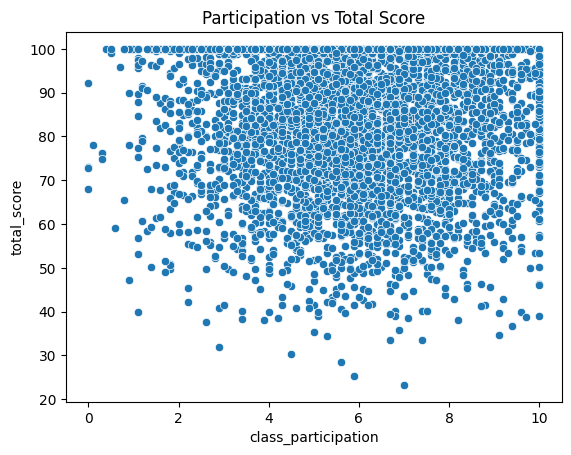

In [ ]:
sns.scatterplot(
    x="class_participation",
    y="total_score",
    data=df.sample(5000)
)
plt.title("Participation vs Total Score")
plt.show()

La participación en clase no muestra una relación clara con el puntaje total.

Los valores están dispersos y no siguen una tendencia definida, lo que indica que esta variable no aporta demasiada información con respecto al dataset

## Conclusión del análisis

Entre las variables analizadas, las horas de estudio muestran la relación más clara con el puntaje total.

Por otro lado, la asistencia y la participación presentan poca o ninguna relación observable, lo que sugiere que su impacto en el rendimiento es limitado en este dataset.

Ahora que tenemos el EDA listo, procedemos con la preparación del dataset

In [ ]:
x = df[["weekly_self_study_hours", "attendance_percentage", "class_participation"]]
y = df["at_risk"]

## 🔀 Train/Test Split
Usamos `stratify=y` para mantener la misma proporción de `at_risk` (que está muy desbalanceada) tanto en train como en test.

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", x_train.shape, "| Test:", x_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (800000, 3) | Test: (200000, 3)
at_risk
0    0.993796
1    0.006204
Name: proportion, dtype: float64
at_risk
0    0.993795
1    0.006205
Name: proportion, dtype: float64


## 🤖 Modelo baseline: Regresión Logística
Empezamos con un modelo simple. Usamos `class_weight='balanced'` porque el target está muy desbalanceado (<1% en riesgo).

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
log_reg = LogisticRegression(class_weight="balanced", random_state=42)
log_reg.fit(x_train_scaled, y_train)
y_pred_log = log_reg.predict(x_test_scaled)

## 📈 Evaluación del baseline
Como el target está desbalanceado, no usamos solo `accuracy`. Nos enfocamos en `recall` de la clase 1 (at_risk), precision, f1-score y la matriz de confusión.

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    198759
           1       0.06      0.94      0.12      1241

    accuracy                           0.91    200000
   macro avg       0.53      0.93      0.53    200000
weighted avg       0.99      0.91      0.95    200000



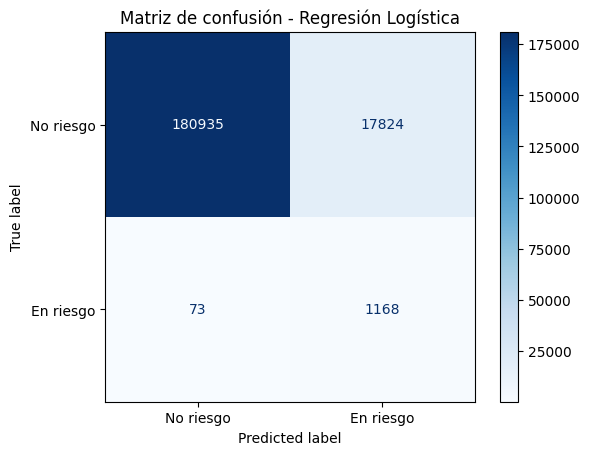

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_test, y_pred_log))
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No riesgo", "En riesgo"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

## 🌲 Random Forest
El empleo de este modelo nos permite capturar relaciones no lineales, algo que la correlación lineal no mostró para `attendance_percentage` y `class_participation`.

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    198759
           1       0.13      0.08      0.10      1241

    accuracy                           0.99    200000
   macro avg       0.56      0.54      0.55    200000
weighted avg       0.99      0.99      0.99    200000



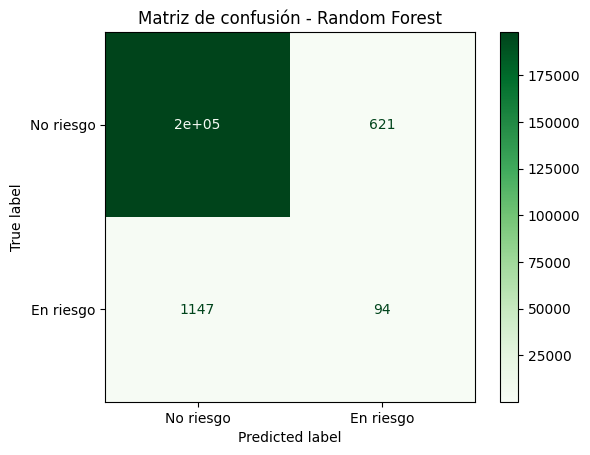

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(  n_estimators=200,  class_weight="balanced",  random_state=42,  n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No riesgo", "En riesgo"])
disp_rf.plot(cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.show()

## 🔍 Importancia de variables (Random Forest)

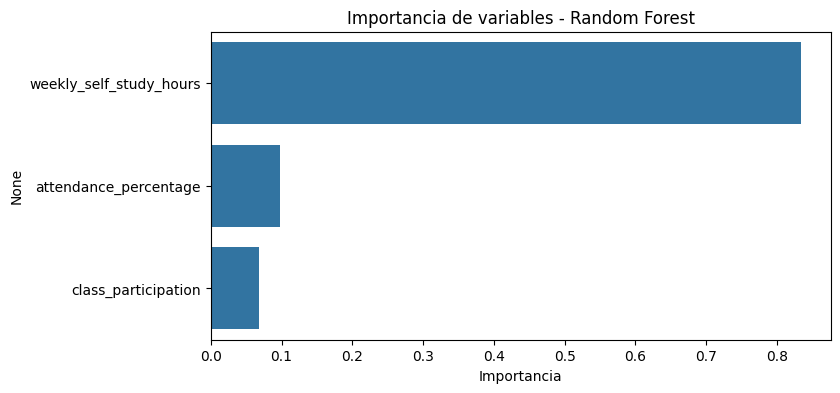

,0
weekly_self_study_hours,0.834255
attendance_percentage,0.097735
class_participation,0.068010


In [25]:
importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.show()
importances

## 📊 Curva ROC y AUC

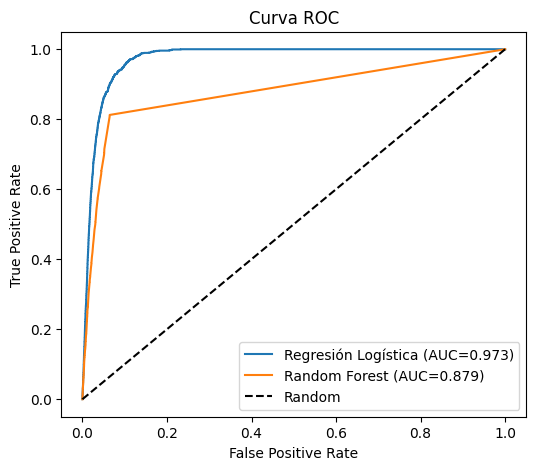

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
y_proba_log = log_reg.predict_proba(x_test_scaled)[:, 1]
y_proba_rf = rf.predict_proba(x_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"Regresión Logística (AUC={auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot([0,1],[0,1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

## ✅ Conclusión
Se compararon dos modelos para predecir `at_risk` usando únicamente señales tempranas (`weekly_self_study_hours`, `attendance_percentage`, `class_participation`), **sin usar `total_score`** para evitar data leakage.
Gracias al `class_weight="balanced"` y al enfoque en recall/f1 (en vez de accuracy), el modelo puede detectar mejor a los estudiantes en riesgo a pesar del fuerte desbalance de clases (<1%).